# Cancer FTIR — multi-model classification (v3: fair deep-learning pipeline)

**BM3 — Image-based Cancer Cell Detection using Deep Learning** (Rafay Nisar).

Same four-model comparison across **Lung / Breast / Colon**, deep models trained fairly:

- **mini-batch training** + **validation split + early stopping**
- **spectral augmentation** = noise + scaling only (NO wavenumber shift — FTIR peaks are at fixed positions, shifting them corrupts the signal)
- **balanced sampling + class-weighted loss**

Models: PCA-LDA, Random Forest (baselines) vs 1D-CNN, 1D-ResNet (deep).

Runtime -> **T4 GPU**, then **Run all**. **Untested by me — paste any error and I'll fix it.**

In [ ]:
!pip -q install scikit-learn scipy openpyxl
import numpy as np, pandas as pd, os
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Cancer Dataset/July2026 Spectroscopy data1'

CONFIG = {
    'Lung':   {'cancer': [f'{BASE}/Lungs/Lung-A549-raw.xlsx',  f'{BASE}/Lungs/Lung-CALU1-raw.xlsx'],
               'pbmc':    f'{BASE}/Lungs/Lung-PBMC-raw.xlsx'},
    'Breast': {'cancer': [f'{BASE}/Breast/Breast-MCF7-raw.xlsx', f'{BASE}/Breast/Breast-BT549-raw.xlsx'],
               'pbmc':    f'{BASE}/Breast/Breast-PBMC-raw.xlsx'},
    'Colon':  {'cancer': [f'{BASE}/Colon/Colon-CACO2-raw.xlsx', f'{BASE}/Colon/Colon-HCA7-raw.xlsx'],
               'pbmc':    f'{BASE}/Colon/Colon-PBMC-raw.xlsx'},
}
for c, cfg in CONFIG.items():
    miss = [f for f in cfg['cancer'] + [cfg['pbmc']] if not os.path.exists(f)]
    print(c, 'OK' if not miss else 'MISSING -> ' + str(miss))

Mounted at /content/drive
Lung OK
Breast OK
Colon OK


In [ ]:
for c, cfg in CONFIG.items():
    n = [pd.read_excel(f, header=None).shape[0] - 1 for f in cfg['cancer'] + [cfg['pbmc']]]
    print(f"{c}: cancer lines = {n[0]} + {n[1]} = {n[0]+n[1]} | PBMC = {n[2]} | total = {sum(n)}")

Lung: cancer lines = 50 + 49 = 99 | PBMC = 50 | total = 149
Breast: cancer lines = 100 + 100 = 200 | PBMC = 100 | total = 300
Colon: cancer lines = 100 + 100 = 200 | PBMC = 100 | total = 300


## 1. Loader + preprocessing

In [ ]:
def read_file(path):
    df = pd.read_excel(path, header=None)
    wn = pd.to_numeric(df.iloc[0, 1:], errors='coerce').to_numpy()
    X = df.iloc[1:, 1:].apply(pd.to_numeric, errors='coerce').to_numpy()
    keep = ~np.isnan(wn)
    return wn[keep], np.nan_to_num(X[:, keep])

def resample(wn, X, grid):
    o = np.argsort(wn)
    return np.vstack([np.interp(grid, wn[o], x[o]) for x in X]) if len(X) else X.reshape(0, len(grid))

def load_prep(cancer_files, pbmc_file, seed=42):
    wn0, _ = read_file(cancer_files[0]); grid = np.sort(wn0)
    Xall, yall = [], []
    for f in cancer_files:
        wn, X = read_file(f); Xall.append(resample(wn, X, grid)); yall += [1] * len(X)
    wn, X = read_file(pbmc_file); Xall.append(resample(wn, X, grid)); yall += [0] * len(X)
    X = np.vstack(Xall); y = np.array(yall)
    Xs = savgol_filter(X, 11, 2, axis=1)
    Xs = (Xs - Xs.mean(1, keepdims=True)) / (Xs.std(1, keepdims=True) + 1e-8)
    return train_test_split(Xs, y, test_size=0.25, stratify=y, random_state=seed)

## 2. Models + fair deep-training pipeline

Augmentation = noise + scaling only (no shift). Mini-batches, balanced sampler, early stopping on validation macro-F1.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
dev = 'cuda' if torch.cuda.is_available() else 'cpu'

class CNN1D(nn.Module):
    def __init__(self, nclass=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3), nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, 5, padding=2), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3), nn.AdaptiveAvgPool1d(1))
        self.fc = nn.Linear(64, nclass)
    def forward(self, x):
        return self.fc(self.net(x).squeeze(-1))

class ResBlock1D(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.c1 = nn.Conv1d(c, c, 3, padding=1); self.b1 = nn.BatchNorm1d(c)
        self.c2 = nn.Conv1d(c, c, 3, padding=1); self.b2 = nn.BatchNorm1d(c)
    def forward(self, x):
        h = torch.relu(self.b1(self.c1(x))); h = self.b2(self.c2(h))
        return torch.relu(h + x)

class ResNet1D(nn.Module):
    def __init__(self, nclass=2):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(1, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2))
        self.blocks = nn.Sequential(ResBlock1D(32), ResBlock1D(32), ResBlock1D(32))
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(32, nclass))
    def forward(self, x):
        return self.head(self.blocks(self.stem(x)))

class SpecDS(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X.astype('float32'); self.y = y.astype('int64'); self.augment = augment
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        x = self.X[i].copy()
        if self.augment:
            if np.random.rand() < 0.5: x = x + np.random.normal(0, 0.05, x.shape).astype('float32')
            if np.random.rand() < 0.5: x = x * np.float32(np.random.uniform(0.95, 1.05))
            # no wavenumber shift: FTIR peaks are at fixed positions, shifting corrupts them
        return torch.tensor(x).unsqueeze(0), int(self.y[i])

def train_torch(make_model, Xtr, ytr, Xte, epochs=200, patience=25, bs=32):
    Xt, Xv, yt, yv = train_test_split(Xtr, ytr, test_size=0.2, stratify=ytr, random_state=0)
    cnt = np.bincount(yt, minlength=2); wper = 1.0 / np.maximum(cnt, 1)
    sampler = WeightedRandomSampler(wper[yt], len(yt), replacement=True)
    tl = DataLoader(SpecDS(Xt, yt, augment=True), batch_size=bs, sampler=sampler)
    model = make_model().to(dev)
    cw = torch.tensor(wper / wper.sum() * 2, dtype=torch.float32).to(dev)
    crit = nn.CrossEntropyLoss(weight=cw)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    Xv_t = torch.tensor(Xv, dtype=torch.float32).unsqueeze(1).to(dev)
    best_f1, best_state, wait = -1, None, 0
    for ep in range(epochs):
        model.train()
        for xb, yb in tl:
            xb, yb = xb.to(dev), yb.to(dev)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vp = model(Xv_t).argmax(1).cpu().numpy()
        f1 = f1_score(yv, vp, average='macro')
        if f1 > best_f1:
            best_f1 = f1; best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}; wait = 0
        else:
            wait += 1
            if wait >= patience: break
    model.load_state_dict(best_state); model.eval()
    Xte_t = torch.tensor(Xte, dtype=torch.float32).unsqueeze(1).to(dev)
    with torch.no_grad():
        return model(Xte_t).argmax(1).cpu().numpy()

def run_all(Xtr, Xte, ytr, yte):
    out = {}
    pl = make_pipeline(PCA(n_components=min(30, Xtr.shape[0]-1)), LinearDiscriminantAnalysis())
    pl.fit(Xtr, ytr); p = pl.predict(Xte)
    out['PCA-LDA'] = (accuracy_score(yte, p), f1_score(yte, p, average='macro'))
    rf = RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42)
    rf.fit(Xtr, ytr); p = rf.predict(Xte)
    out['RandomForest'] = (accuracy_score(yte, p), f1_score(yte, p, average='macro'))
    for name, mk in [('1D-CNN', CNN1D), ('1D-ResNet', ResNet1D)]:
        p = train_torch(mk, Xtr, ytr, Xte)
        out[name] = (accuracy_score(yte, p), f1_score(yte, p, average='macro'))
    return out

## 3. Run every cancer type through every model

In [ ]:
rows = []
for cancer, cfg in CONFIG.items():
    try:
        Xtr, Xte, ytr, yte = load_prep(cfg['cancer'], cfg['pbmc'])
    except Exception as e:
        print(f'[SKIP] {cancer}: {e}'); continue
    print(f'{cancer}: train {Xtr.shape[0]}  test {Xte.shape[0]}  (cancer {int((ytr==1).sum()+(yte==1).sum())} / PBMC {int((ytr==0).sum()+(yte==0).sum())})')
    for model, (acc, f1) in run_all(Xtr, Xte, ytr, yte).items():
        rows.append({'cancer': cancer, 'model': model, 'accuracy': round(acc, 3), 'macro_F1': round(f1, 3)})
print('done')

Lung: train 111  test 38  (cancer 99 / PBMC 50)
Breast: train 225  test 75  (cancer 200 / PBMC 100)
Colon: train 225  test 75  (cancer 200 / PBMC 100)
done


## 4. Combined results (cancer type x model)

In [ ]:
res = pd.DataFrame(rows)
print('=== macro-F1 (use THIS, not accuracy) ===')
print(res.pivot(index='cancer', columns='model', values='macro_F1').to_string())
print('\n=== accuracy ===')
print(res.pivot(index='cancer', columns='model', values='accuracy').to_string())
res.to_csv('/content/drive/MyDrive/ftir_allcancers_results_v3.csv', index=False)
print('\nsaved -> ftir_allcancers_results_v3.csv')

=== macro-F1 (use THIS, not accuracy) ===
model   1D-CNN  1D-ResNet  PCA-LDA  RandomForest
cancer                                          
Breast   0.737      0.955    1.000         0.924
Colon    0.753      0.820    0.954         0.886
Lung     0.766      0.883    0.970         0.939

=== accuracy ===
model   1D-CNN  1D-ResNet  PCA-LDA  RandomForest
cancer                                          
Breast   0.773      0.960    1.000         0.933
Colon    0.760      0.827    0.960         0.907
Lung     0.789      0.895    0.974         0.947

saved -> ftir_allcancers_results_v3.csv


In [ ]:
import pandas as pd, os
BASE='/content/drive/MyDrive/Cancer Dataset/July2026 Spectroscopy data1'  # or your path
for c,fs in {'Lung':['Lungs/Lung-A549-raw.xlsx','Lungs/Lung-CALU1-raw.xlsx','Lungs/Lung-PBMC-raw.xlsx'],
 'Breast':['Breast/Breast-MCF7-raw.xlsx','Breast/Breast-BT549-raw.xlsx','Breast/Breast-PBMC-raw.xlsx'],
 'Colon':['Colon/Colon-CACO2-raw.xlsx','Colon/Colon-HCA7-raw.xlsx','Colon/Colon-PBMC-raw.xlsx']}.items():
    print(c,[pd.read_excel(os.path.join(BASE,f),header=None).shape[0]-1 for f in fs])

Lung [50, 49, 50]
Breast [100, 100, 100]
Colon [100, 100, 100]



===== Lung — PCA-LDA =====
              precision    recall  f1-score   support

        PBMC      1.000     1.000     1.000        13
      Cancer      1.000     1.000     1.000        25

    accuracy                          1.000        38
   macro avg      1.000     1.000     1.000        38
weighted avg      1.000     1.000     1.000        38


===== Lung — RandomForest =====
              precision    recall  f1-score   support

        PBMC      1.000     1.000     1.000        13
      Cancer      1.000     1.000     1.000        25

    accuracy                          1.000        38
   macro avg      1.000     1.000     1.000        38
weighted avg      1.000     1.000     1.000        38


===== Lung — 1D-CNN =====
              precision    recall  f1-score   support

        PBMC      0.786     0.846     0.815        13
      Cancer      0.917     0.880     0.898        25

    accuracy                          0.868        38
   macro avg      0.851     0.863     0.

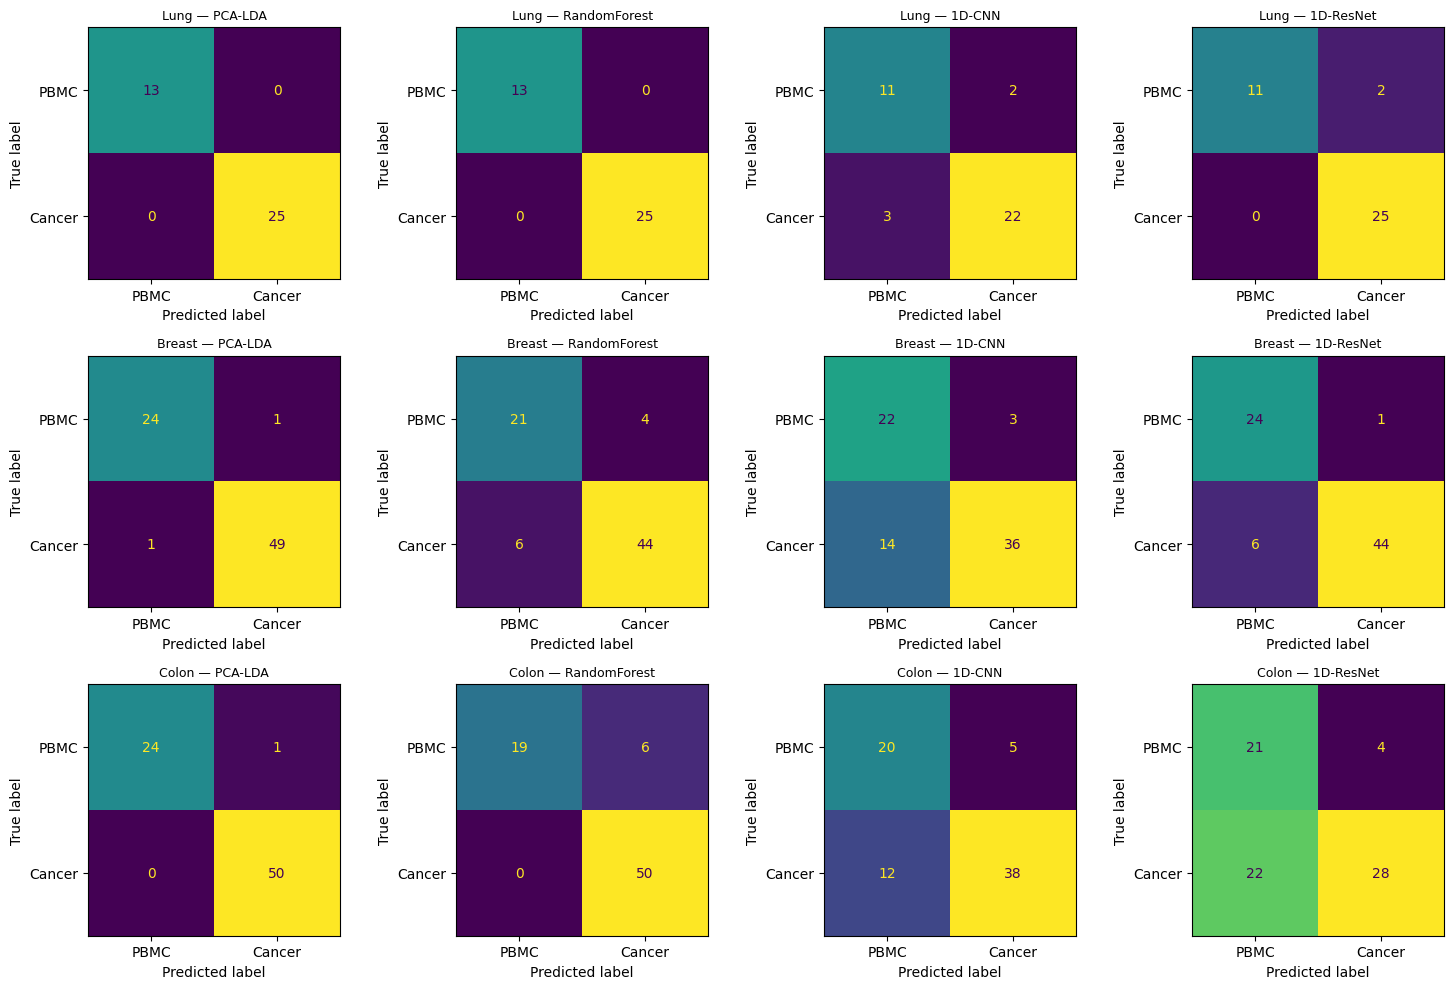

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt, numpy as np, torch
torch.manual_seed(0); np.random.seed(0)

fig, axes = plt.subplots(3, 4, figsize=(15, 10))
names = ['PCA-LDA', 'RandomForest', '1D-CNN', '1D-ResNet']
for r, (cancer, cfg) in enumerate(CONFIG.items()):
    Xtr, Xte, ytr, yte = load_prep(cfg['cancer'], cfg['pbmc'], seed=0)
    preds = {}
    preds['PCA-LDA'] = make_pipeline(PCA(n_components=min(30, Xtr.shape[0]-1)), LinearDiscriminantAnalysis()).fit(Xtr, ytr).predict(Xte)
    preds['RandomForest'] = RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=0).fit(Xtr, ytr).predict(Xte)
    preds['1D-CNN'] = train_torch(CNN1D, Xtr, ytr, Xte)      # no seed arg
    preds['1D-ResNet'] = train_torch(ResNet1D, Xtr, ytr, Xte)
    for c, name in enumerate(names):
        print(f'\n===== {cancer} — {name} =====')
        print(classification_report(yte, preds[name], target_names=['PBMC', 'Cancer'], digits=3))
        ConfusionMatrixDisplay(confusion_matrix(yte, preds[name]), display_labels=['PBMC', 'Cancer']).plot(ax=axes[r, c], colorbar=False)
        axes[r, c].set_title(f'{cancer} — {name}', fontsize=9)
plt.tight_layout(); plt.savefig('/content/drive/MyDrive/ftir_confusion_grid.png', dpi=140); plt.show()

In [ ]:
import numpy as np, pandas as pd, os, joblib
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
BASE = '/content/drive/MyDrive/Cancer Dataset/July2026 Spectroscopy data1'   # your path
FILES = {'Lung':[('Lungs/Lung-A549-raw.xlsx',1),('Lungs/Lung-CALU1-raw.xlsx',1),('Lungs/Lung-PBMC-raw.xlsx',0)],
 'Breast':[('Breast/Breast-MCF7-raw.xlsx',1),('Breast/Breast-BT549-raw.xlsx',1),('Breast/Breast-PBMC-raw.xlsx',0)],
 'Colon':[('Colon/Colon-CACO2-raw.xlsx',1),('Colon/Colon-HCA7-raw.xlsx',1),('Colon/Colon-PBMC-raw.xlsx',0)]}
def read_file(p):
    df=pd.read_excel(p,header=None); wn=pd.to_numeric(df.iloc[0,1:],errors='coerce').to_numpy()
    X=df.iloc[1:,1:].apply(pd.to_numeric,errors='coerce').to_numpy(); k=~np.isnan(wn)
    return wn[k], np.nan_to_num(X[:,k])
wn0,_=read_file(os.path.join(BASE,'Lungs/Lung-A549-raw.xlsx')); grid=np.sort(wn0)
def rs(wn,X): o=np.argsort(wn); return np.vstack([np.interp(grid,wn[o],x[o]) for x in X])
Xa,ya=[],[]
for c,fs in FILES.items():
    for f,lab in fs:
        wn,X=read_file(os.path.join(BASE,f)); Xa.append(rs(wn,X)); ya+=[lab]*len(X)
X=np.vstack(Xa); y=np.array(ya)
Xs=savgol_filter(X,11,2,axis=1); Xs=(Xs-Xs.mean(1,keepdims=True))/(Xs.std(1,keepdims=True)+1e-8)
model=make_pipeline(PCA(n_components=30),LinearDiscriminantAnalysis()).fit(Xs,y)
joblib.dump({'model':model,'grid':grid},'/content/drive/MyDrive/ftir_pcalda.joblib')
print('saved ftir_pcalda.joblib | trained on',len(y),'spectra (cancer',int((y==1).sum()),'/ PBMC',int((y==0).sum()),')')

saved ftir_pcalda.joblib | trained on 749 spectra (cancer 499 / PBMC 250 )


## 5. Read the result

- Lung deep models should recover now the corrupting shift-augmentation is gone.
- Final honest headline: does any deep model match/beat PCA-LDA? If PCA-LDA still leads, that is a valid finding (classical stays strongest on small single-cell FTIR, consistent with Dowling).
- FTIR track is now complete; deep learning moves to the imaging modality.